# This notebook assembles BEEF correlations [calculated by the Goldsmith group](https://github.com/franklingoldsmith/thermo_kinetics_scripts) and exports them to an RMG-UQ compatible format

### Part 1. surfaceThermoPt111 library correlations
### Part 2. Pt111 adsorption correction tree correlations


In [1]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import shutil
import glob
import subprocess

import rmgpy.data.thermo
import rmgpy.data.rmg
import rmgpy.chemkin

import matplotlib.pyplot as plt
%matplotlib inline

# Part 0: Setup
### - Download the repository containing the surface thermo calculations
### - Set the `THERMO_DATA_PATH` variable

Unfortunately, the exact locations of these files might change as the repo gets updated, but we're looking for folder titled `beef-ensembles` which is full of files like XCHOO_bee.txt that contain the ensemble data

### You can manually download the repository here: https://github.com/franklingoldsmith/thermo_kinetics_scripts or run the next cell

In [2]:
# These are the commands:
os.chdir(os.environ['HOME'])  # assumes we will clone thermo_kinetics_scripts into our home folder

THERMO_DATA_PATH = os.path.join(os.environ['HOME'], 'thermo_kinetics_scripts/beef-uq/thermo/beef-ensembles')
example_bee_file = os.path.join(THERMO_DATA_PATH, 'XH_bee.txt')

if not os.path.exists(example_bee_file):
    subprocess.check_call(['git', 'clone', 'https://github.com/franklingoldsmith/thermo_kinetics_scripts'])

assert os.path.exists(example_bee_file), 'either download failed or file structure of repo has changed'

# Part 1: surfaceThermoPt111 library correlations

### 1.1 Load the copy of surfaceThermoPt111.py in this repository to get the molecule structures

In [3]:
# load their thermo library
thermo_lib_file = os.path.join(os.environ['HOME'], 'thermo_kinetics_scripts/beef-uq/thermo/surfaceThermoPt111.py')

# RMG expects the library in its own directory
lib_dir = os.path.join(os.path.dirname(thermo_lib_file), 'lib')
os.makedirs(lib_dir, exist_ok=True)
shutil.copyfile(thermo_lib_file, os.path.join(lib_dir, os.path.basename(thermo_lib_file)))

thermo_database = rmgpy.data.thermo.ThermoDatabase()
thermo_database.load_libraries(lib_dir)

# Make a list of each molecule and each label
items = [thermo_database.libraries['surfaceThermoPt111'].entries[e].item for e in thermo_database.libraries['surfaceThermoPt111'].entries]
labels = [thermo_database.libraries['surfaceThermoPt111'].entries[e].label for e in thermo_database.libraries['surfaceThermoPt111'].entries]

### 1.2 Load all the data from the BEE files

In [4]:
def get_name_from_path(path):
    search_pattern = r'beef-ensembles/(.+)_bee.txt'
    m1 = re.search(search_pattern, path)
    if m1 is not None:
        return m1[1]
bee_files = sorted(glob.glob(os.path.join(THERMO_DATA_PATH, '*_bee.txt')))

### 1.3 Function to match BEEF data to names in library

In [5]:
def get_molecule_by_name(sp_name):
    # Get the molecule that matches the name in the BEEF thermo library
    try:
        entry_index = labels.index(sp_name)
        return items[entry_index]
    except ValueError:
        print(f'Could not find {i} {sp_name} in thermo library')
        return None

### 1.4 Load BEEF thermo ensemble data and corresponding molecule structure

In [6]:
Hf_ensemble_data = []
molecules = []
for i in range(len(bee_files)):
    species_name = get_name_from_path(bee_files[i])
    molecule = get_molecule_by_name(species_name)
    if molecule is None:
        continue
    molecules.append(molecule)

    species_ensemble_data = []
    # the loaded dataframe has 2 columns: Hf and Delta Hf
    df = pd.read_csv(bee_files[i], sep='\t')
    Hf_ensemble_data.append(df['Hf'].values)

Hf_ensemble_data = np.array(Hf_ensemble_data)

assert Hf_ensemble_data.shape[1] == 2000, 'BEEF ensemble size should be 2000'

N_species = Hf_ensemble_data.shape[0]
print(f'{N_species} species loaded')

cov_Hf = np.cov(Hf_ensemble_data)
assert cov_Hf.shape[0] == N_species
assert len(molecules) == N_species

Could not find 18 CH3OXCO in thermo library
182 species loaded


### 1.5 Check that the results make sense

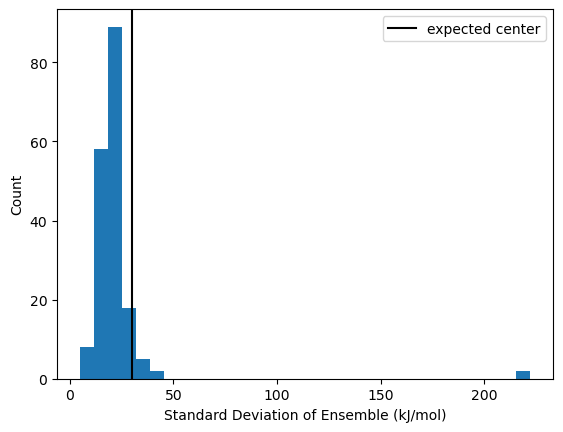

In [7]:
# as of 2026, the BEEF errors should be on the order of 30 kJ/mol, but this may change over time!
assert np.sum(np.diagonal(cov_Hf) == 0) == 0, 'There should not be any zeros in the diagonal of the covariance matrix'
assert np.sum(np.isnan(cov_Hf)) == 0, 'There should not be any nans in the covariance matrix'

tolerance = 1e-12
assert np.linalg.eigvals(cov_Hf).all() > -tolerance, 'Covariance matrix should be positive semidefinite'

diagonal = np.diagonal(cov_Hf)
plt.figure()
plt.hist(np.sqrt(diagonal), bins=32)
plt.axvline(x=30, color='black', label='expected center')
plt.ylabel('Count')
plt.xlabel('Standard Deviation of Ensemble (kJ/mol)')
plt.legend()

# check that the mean uncertainty is +/- 10 kJ/mol of the expected 30 kJ/mol
assert np.isclose(np.mean(np.sqrt(diagonal)), 30, atol=10.0)


Text(0.5, 1.0, 'Thermo Covariance Matrix')

<Figure size 640x480 with 0 Axes>

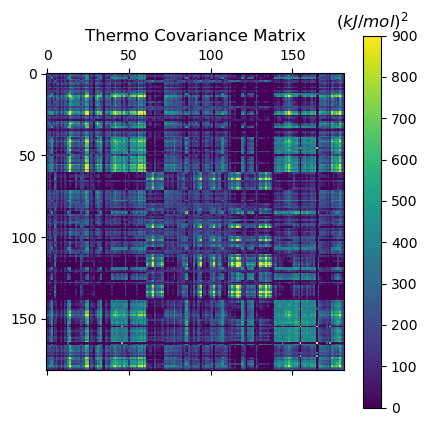

In [8]:
plt.figure()
# Look at the covariance matrix
plt.matshow(cov_Hf)
cb = plt.colorbar()
plt.clim([0, 30 ** 2])
cb.ax.set_title(r'$(kJ/mol)^2$')
plt.title('Thermo Covariance Matrix')

### 1.6 Save files

In [9]:
lib_name = os.path.basename(thermo_lib_file).replace('.py', '')
thermo_uncertainty_dir = os.path.join(rmgpy.settings['database.directory'], 'thermo', 'uncertainty', lib_name)
os.makedirs(thermo_uncertainty_dir, exist_ok=True)

cov_mat_file = os.path.join(thermo_uncertainty_dir, 'covariance.npy')
np.save(cov_mat_file, cov_Hf)

# labels need to be unique, and shorter than 16 characters
spec_list = []
for i in range(len(molecules)):
    spec = rmgpy.species.Species(molecule=[molecules[i]])
    spec.label = f'{molecules[i].smiles}({i})'
    if len(spec.label) > 10:  # <----- try decreasing this if not all species are saved
        spec.label = molecules[i].get_formula() + f'({i})'
    spec_list.append(spec)

rmgpy.chemkin.save_species_dictionary(
    os.path.join(thermo_uncertainty_dir, 'species_dictionary.txt'),
    spec_list,
)

# read it back in to check we didn't lose any
sp_dict = rmgpy.chemkin.load_species_dictionary(os.path.join(thermo_uncertainty_dir, 'species_dictionary.txt'))
assert len(sp_dict) == len(molecules), 'not all species were saved, try decreasing label length limit'

# Part 2: Pt111 adsorption correction tree correlations

### 2.1 Load the adsorption correction tree from the database

In [10]:
database = rmgpy.data.rmg.RMGDatabase()

database.load(
    path = rmgpy.settings['database.directory'],
    thermo_libraries = ['surfaceThermoPt111', 'primaryThermoLibrary'],
    transport_libraries = [],
    reaction_libraries = [],
    seed_mechanisms = [],
    kinetics_families = 'none',
    kinetics_depositories = ['training'],
    depository = False,
)

### 2.2 Flatten the adsorption correction tree groups into a single list of nodes

In [11]:
# get a list of all the adsorption correction groups
ads_group_items = [database.thermo.groups['adsorptionPt111'].entries[key].item for key in database.thermo.groups['adsorptionPt111'].entries]
ads_group_labels = [key for key in database.thermo.groups['adsorptionPt111'].entries]
assert len(ads_group_items) == len(ads_group_labels)

# make a list with all groups and training species because we also want to correlate the adsorption groups with the surfaceThermoPt111 library
all_items = ads_group_items + molecules


### 2.3 Calculate covariance of the groups and training data.
#### - Assumes any training species that is subgraph isomorphic with a group is used to train that node.
#### - Also assumes each training species contributes with equal weight

In [12]:
# Make a giant matrix called ads_ensembles
# its size is (#group nodes + #species) x 2000 and it holds all the group + training species ensemble data
# Once it's filled in, we can call np.cov(ads_ensembles) to get the covariance matrix of the adsorption tree nodes
N = 2000  # size of ensemble
n_groups = len(ads_group_items)
n_molecules = len(molecules)
ads_ensembles = np.zeros((len(all_items), N))

def training_molecule_fits_group(training_molecule, group):
    # check if a species matches the general description of the group node
    return training_molecule.is_subgraph_isomorphic(group, generate_initial_map=True)

# Construct ensemble matrix for groups as average of training data
for i in range(n_groups):
    # get all molecules that match that node
    n_training_mols = 0
    for j in range(n_molecules):
        if training_molecule_fits_group(molecules[j], ads_group_items[i]):
        # if all_items[n_groups + j].is_subgraph_isomorphic(reconstructed_items[i], generate_initial_map=True):
            ads_ensembles[i, :] += Hf_ensemble_data[j, :]
            n_training_mols += 1
    
    if n_training_mols > 0:
        ads_ensembles[i, :] /= n_training_mols
    else:
        ads_ensembles[i, :] = np.nan  # no data

# also fill in the individual species        
for i in range(n_molecules):
    ads_ensembles[n_groups + i, :] += Hf_ensemble_data[i, :]

cov_ads = np.cov(ads_ensembles)  # units are (kJ/mol) ^2

### 2.4 Check that the results make sense

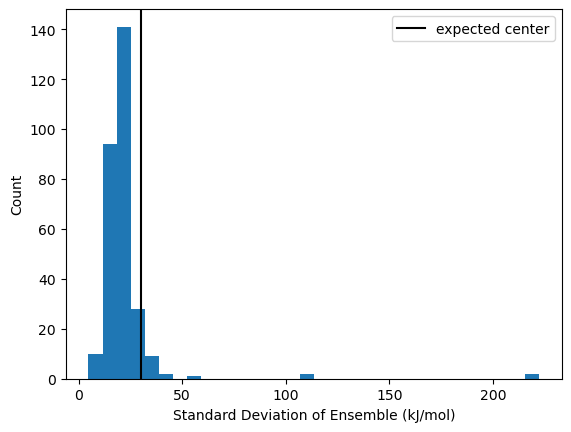

In [13]:
# as of 2026, the BEEF errors should be on the order of 30 kJ/mol, but this may change over time!
# For this covariance matrix, we expect 

# for i in range(cov_ads.shape[0]):
#     if np.isnan(cov_ads[i, i]):
#         print(f'Index {i} {all_items[i]} is missing data:')
#         display(all_items[i])
# assert np.sum(np.isnan(cov_ads)) == 0, 'Ideally, there should not be any nans in the covariance matrix'

# tolerance = 1e-12
# assert np.linalg.eigvals(cov_ads).all() > -tolerance, 'Covariance matrix should be positive semidefinite'

diagonal = np.diagonal(cov_ads)
plt.figure()
plt.hist(np.sqrt(diagonal), bins=32)
plt.axvline(x=30, color='black', label='expected center')
plt.ylabel('Count')
plt.xlabel('Standard Deviation of Ensemble (kJ/mol)')
plt.legend()

# check that the mean uncertainty is +/- 10 kJ/mol of the expected 30 kJ/mol
assert np.isclose(np.nanmean(np.sqrt(diagonal)), 30, atol=10.0)

Text(0.5, 1.0, 'Thermo Covariance Matrix')

<Figure size 640x480 with 0 Axes>

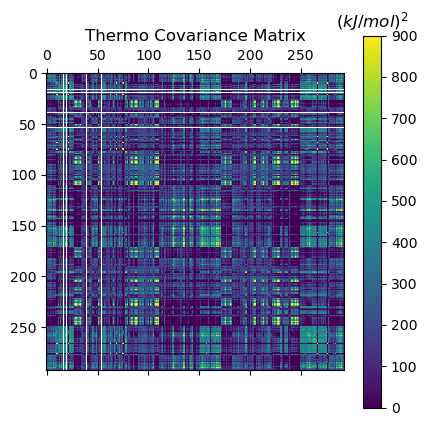

In [14]:
plt.figure()
# Look at the covariance matrix
plt.matshow(cov_ads)
cb = plt.colorbar()
plt.clim([0, 30 ** 2])
cb.ax.set_title(r'$(kJ/mol)^2$')
plt.title('Thermo Covariance Matrix')


### 2.5 Save the results

In [15]:
ads_thermo_uncertainty_dir = os.path.join(rmgpy.settings['database.directory'], 'thermo', 'uncertainty', 'adsorptionPt111')
os.makedirs(ads_thermo_uncertainty_dir, exist_ok=True)

ads_cov_mat_file = os.path.join(ads_thermo_uncertainty_dir, 'covariance.npy')
np.save(ads_cov_mat_file, cov_ads)

# save molecules and groups separately because it's impossible to disambiguate if they're combined
# also, groups can't be saved directly using rmgpy.chemkin.save_species_dictionary

# labels need to be unique, and shorter than 16 characters
spec_list = []
for i in range(len(molecules)):
    spec = rmgpy.species.Species(molecule=[molecules[i]])
    spec.label = f'{molecules[i].smiles}({i})'
    if len(spec.label) > 10:  # <----- try decreasing this if not all species are saved
        spec.label = molecules[i].get_formula() + f'({i})'
    spec_list.append(spec)

rmgpy.chemkin.save_species_dictionary(
    os.path.join(ads_thermo_uncertainty_dir, 'species_dictionary.txt'),
    spec_list,
)
# read it back in to check we didn't lose any
sp_dict = rmgpy.chemkin.load_species_dictionary(os.path.join(ads_thermo_uncertainty_dir, 'species_dictionary.txt'))
assert len(sp_dict) == len(molecules), 'not all species were saved, try decreasing label length limit'


# save the groups separately as a ThermoGroup Database
my_group_database = rmgpy.data.thermo.ThermoGroups()
my_group_database.name = "adsorptionPt111 uncertainty groups"
my_group_database.short_desc = "Uncertainty group definitions for adsorbates on Pt(111)"
my_group_database.long_desc = """
This database defines the adsorption-group patterns in the same order as the corresponding covariances.npy.
This is allows the uncertainty analysis to account for correlations when different groups on the same adsorption correction tree
were trained using the same DFT data.
"""
for i in range(len(ads_group_items)):
    entry = rmgpy.data.base.Entry()
    entry.item = ads_group_items[i]
    entry.label = ads_group_labels[i]
    my_group_database.entries[entry.label] = entry
my_group_database.save(os.path.join(ads_thermo_uncertainty_dir, 'groups.py'))


## 3. Spot check some specific covariances to use for direct comparison with RMG UQ

### group-group

In [16]:
ads1 = ads_group_labels.index('C=*RO-*')
ads2 = ads_group_labels.index('C-*RC=*')
print(f'Covariance({ads_group_labels[ads1]}, {ads_group_labels[ads2]}) = {cov_ads[ads1, ads2] / 4.184 / 4.184:0.4f} (kcal/mol)^2')


Covariance(C=*RO-*, C-*RC=*) = 5.1814 (kcal/mol)^2


### group-library

In [17]:
ads1 = ads_group_labels.index('C=*RO-*')

lib2 = -1
for i in range(len(molecules)):
    if molecules[i].is_isomorphic(rmgpy.molecule.Molecule(smiles='OC(=*)C')):
        lib2 = i
        break


print(f'Covariance({ads_group_labels[ads1]}, {molecules[lib2]}) = {cov_ads[ads1, n_groups + lib2] / 4.184 / 4.184:0.4f} (kcal/mol)^2')


Covariance(C=*RO-*, <Molecule "C[C](O)=[Pt]">) = 10.0169 (kcal/mol)^2


### library-library

In [18]:
lib1 = -1
lib2 = -1
for i in range(len(molecules)):
    if molecules[i].is_isomorphic(rmgpy.molecule.Molecule(smiles='C*')):
        lib1 = i
    if molecules[i].is_isomorphic(rmgpy.molecule.Molecule(smiles='[CH2]=*')):
        lib2 = i
    
print(f'Covariance({molecules[lib1]}, {molecules[lib2]}) = {cov_ads[n_groups + lib1, n_groups + lib2] / 4.184 / 4.184:0.4f} (kcal/mol)^2')


Covariance(<Molecule "[CH3][Pt]">, <Molecule "[CH2]=[Pt]">) = 4.2400 (kcal/mol)^2
